<a href="https://colab.research.google.com/github/nisha-moyal/iris-classification/blob/main/iris_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Separate input features and target labels
X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)
Target shape: (150,)


In [6]:
import pandas as pd

# Convert the dataset into a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target species
df["species"] = iris.target_names[iris.target]

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
print("Dataset shape:", df.shape)

print("\nColumn information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSpecies distribution:")
print(df["species"].value_counts())

Dataset shape: (150, 5)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


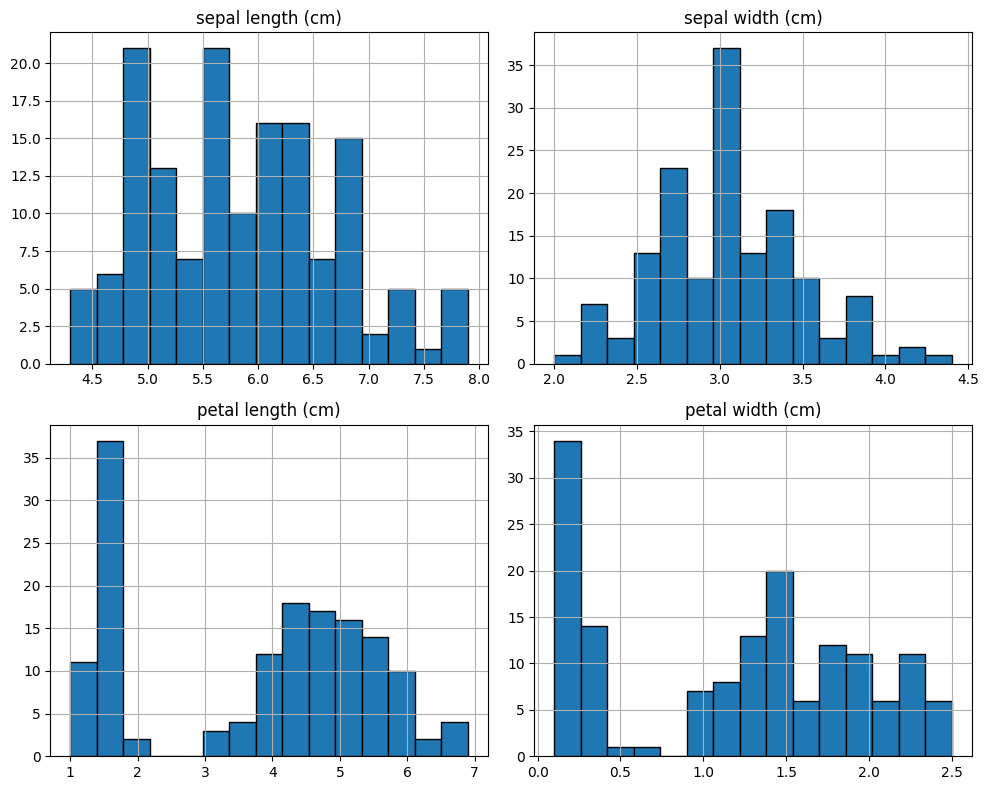

In [12]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 8), bins=15, edgecolor="black")

plt.tight_layout()
plt.show()

In [14]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training labels: (120,)
Testing labels: (30,)


In [15]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=200)

# Train the model using training data
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


### Make predictions

In [16]:

# Predict species for test data
y_pred = model.predict(X_test)

# Compare actual and predicted labels
print("Actual labels:   ", y_test[:10])
print("Predicted labels:", y_pred[:10])

Actual labels:    [0 2 1 1 0 1 0 0 2 1]
Predicted labels: [0 2 1 1 0 1 0 0 2 1]


### Accuracy


Accuracy=Total Predictions/Correct Predictions​

In [18]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.9666666666666667
Model Accuracy (%): 96.66666666666667


### Evaluate each species separately

In [19]:

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [20]:
### Confusion metrics

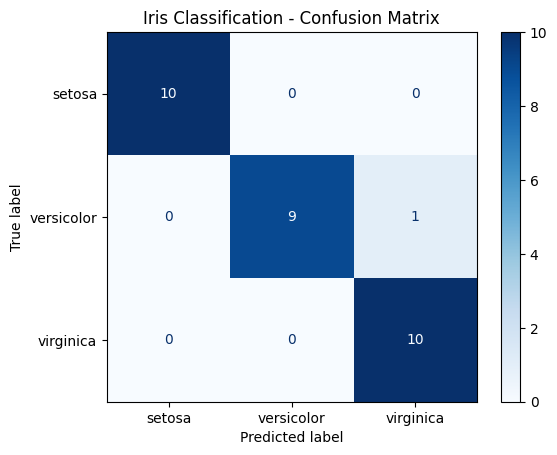

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compare actual labels with predicted labels
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

display.plot(cmap="Blues")
plt.title("Iris Classification - Confusion Matrix")
plt.show()

### Save model

In [22]:

import joblib

# Save the trained model to a file
joblib.dump(model, "iris_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Load saved model

In [23]:

# Load the saved model
loaded_model = joblib.load("iris_model.pkl")

# Predict a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = loaded_model.predict(new_flower)

print("Predicted species:", iris.target_names[prediction[0]])

Predicted species: setosa
